<a href="https://colab.research.google.com/github/eshajain-123/csot-ml-astronomy/blob/main/week4_lens_clip_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets transformers

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [ ]:
from datasets import load_dataset
ds_train = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='train')
ds_test  = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='test')
print(ds_train)
print(ds_test)


README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 5876
})
Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 1476
})


In [ ]:
import numpy as np
y_train = np.array(ds_train['label']); y_test = np.array(ds_test['label'])
print('train:', len(y_train), 'test:', len(y_test))
print('train label counts:', np.bincount(y_train))
print('test  label counts:', np.bincount(y_test))
print('test positive fraction:', y_test.mean())

train: 5876 test: 1476
train label counts: [5482  394]
test  label counts: [1372  104]
test positive fraction: 0.07046070460704607


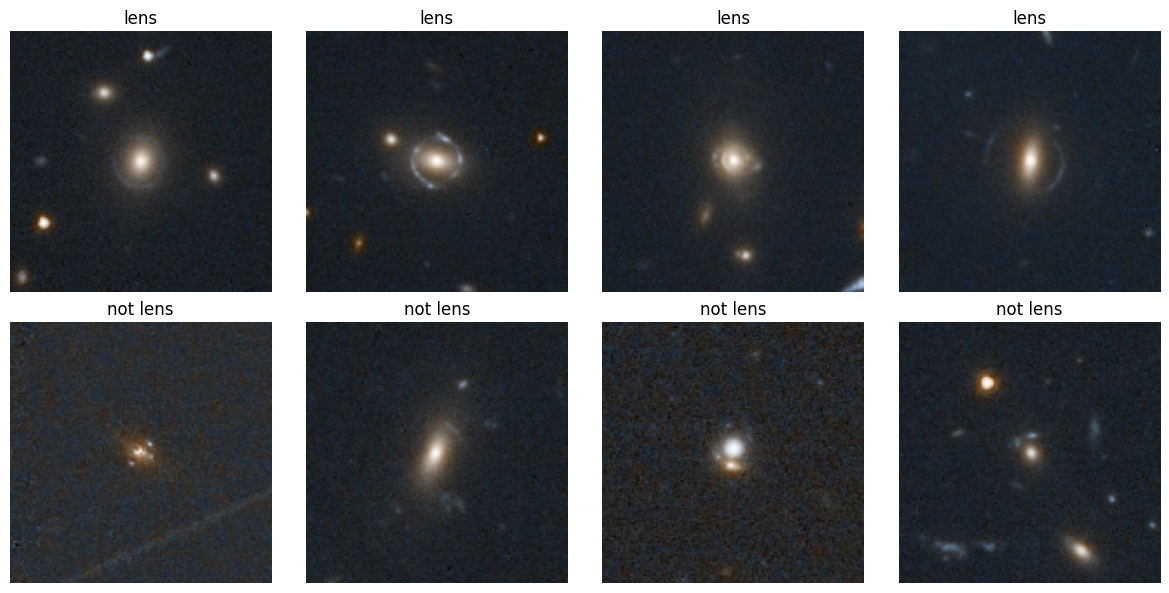

In [ ]:
pos_idx = [i for i, y in enumerate(ds_test['label']) if y == 1][:4]
neg_idx = [i for i, y in enumerate(ds_test['label']) if y == 0][:4]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes[0], pos_idx):
  ax.imshow(ds_test[i]['image']); ax.set_title('lens'); ax.axis('off')
for ax, i in zip(axes[1], neg_idx):
  ax.imshow(ds_test[i]['image']); ax.set_title('not lens'); ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from transformers import CLIPModel, CLIPProcessor
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device).eval()
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
lens_prompts = [
'a strong gravitational lens with an Einstein ring',
'a gravitational lens arc next to a galaxy',
'multiple images of a background source due to gravitational lensing']
nonlens_prompts = [
'a normal galaxy without gravitational lensing',
'a spiral galaxy with curved arms but no gravitational lens arc',
'a smooth elliptical galaxy with no lensing features']
all_prompts = lens_prompts + nonlens_prompts
text_inputs = processor(text=all_prompts, return_tensors='pt', padding=True).to(device)
with torch.no_grad():
  text_emb = model.get_text_features(**text_inputs).pooler_output
  text_emb = F.normalize(text_emb, dim=-1)            # (num_prompts, D)
  n_lens = len(lens_prompts)


In [ ]:
images = [ex.convert('RGB') for ex in ds_test['image']]
img_embs = []
batch = 64
for start in range(0, len(images), batch):
  chunk = images[start:start+batch]
  inputs = processor(images=chunk, return_tensors='pt').to(device)
  with torch.no_grad():
    emb = model.get_image_features(**inputs).pooler_output
  img_embs.append(F.normalize(emb, dim=-1).cpu())
img_emb = torch.cat(img_embs)                       # (N, D)
print(img_emb.shape)

torch.Size([1476, 512])


In [ ]:
sims = img_emb @ text_emb.cpu().T                   # (N, num_prompts)
lens_sim = sims[:, :n_lens].mean(dim=1)
nonlens_sim = sims[:, n_lens:].mean(dim=1)
scores = (lens_sim - nonlens_sim).numpy()
print('score range:', scores.min(), scores.max())

score range: -0.031258374 0.024370253


ROC-AUC: 0.4845256784032294


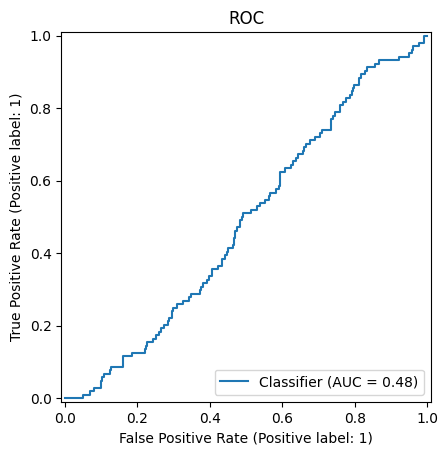

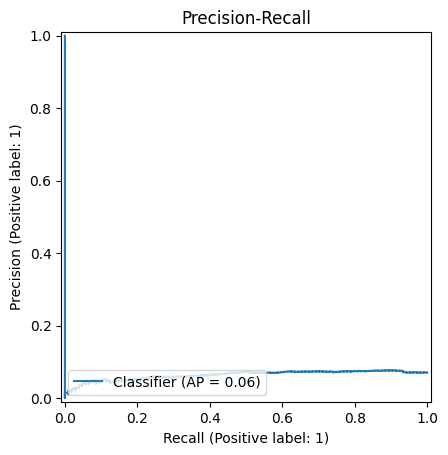

              precision    recall  f1-score   support

           0       0.92      0.80      0.86      1372
           1       0.05      0.12      0.07       104

    accuracy                           0.76      1476
   macro avg       0.48      0.46      0.46      1476
weighted avg       0.86      0.76      0.80      1476



In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay, classification_report
print('ROC-AUC:', roc_auc_score(y_test, scores))
RocCurveDisplay.from_predictions(y_test, scores)
plt.title('ROC')
plt.show()
PrecisionRecallDisplay.from_predictions(y_test, scores); plt.title('Precision-Recall')
plt.show()

t = 0
y_pred = (scores >= t).astype(int)
print(classification_report(y_test, y_pred))


In [ ]:
print(scores.min())
print(scores.max())
print(scores.mean())

-0.031258374
0.024370253
-0.0063482067


In [ ]:
print("Mean score for lenses     :", scores[y_test == 1].mean())
print("Mean score for non-lenses :", scores[y_test == 0].mean())

Mean score for lenses     : -0.007061586
Mean score for non-lenses : -0.0062941317


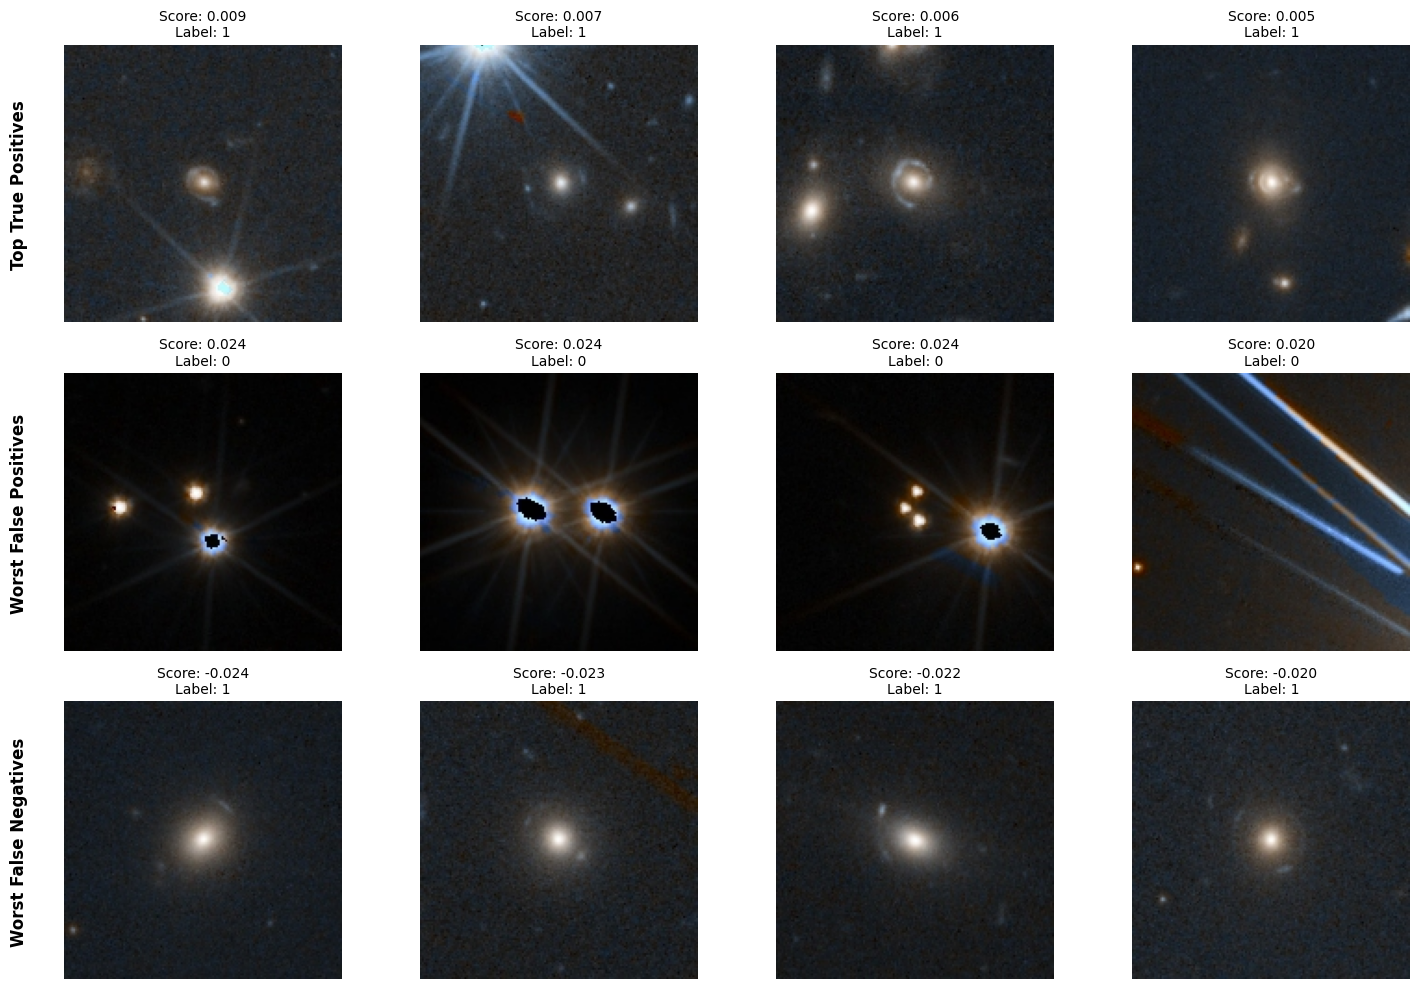

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

order = np.argsort(-scores)  # high score first

top_tp = [i for i in order if y_test[i] == 1][:4]
worst_fp = [i for i in order if y_test[i] == 0][:4]
worst_fn = [i for i in order[::-1] if y_test[i] == 1][:4]

categories = [
    ("Top True Positives", top_tp),
    ("Worst False Positives", worst_fp),
    ("Worst False Negatives", worst_fn)
]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))

for row_idx, (category_name, indices) in enumerate(categories):
    # Fallback default height if a row happens to be empty
    img_height = 224

    for col_idx, i in enumerate(indices):
        ax = axes[row_idx, col_idx]

        idx = int(i)
        img = ds_test[idx]['image']

        # Determine height safely before converting types
        img_height = img.size[1] if hasattr(img, 'size') else img.shape[0]

        # If your image is a tensor, permute it for matplotlib
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).cpu().numpy()

        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Score: {scores[idx]:.3f}\nLabel: {y_test[idx]}", fontsize=10)

    # --- FIX: Uses the safely calculated 'img_height' variable ---
    axes[row_idx, 0].text(-20, img_height // 2, category_name,
                          rotation=90, va='center', ha='right',
                          fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()